# Notebook 04: Exploratory Data Analysis

## Purpose
Explore relationships between stunting and key predictors.

## Objectives
1. Examine distributions  
2. Compare stunting across groups  
3. Identify patterns for modeling  

## Output
outputs/figures/

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Set project paths
PROJECT_ROOT = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"

# Ensure figure folder exists
FIGURES.mkdir(parents=True, exist_ok=True)

# Define plot colors
PRIMARY = "#2E8B57"
SECONDARY = "#E5533D"
ACCENT = "#F4A261"
NEUTRAL = "#6C757D"

# Load processed dataset
df = pd.read_parquet(DATA_PROCESSED / "model_dataset.parquet")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (5415, 9)


,v001,v002,hw70,stunted,v012_x,v106_x,v190_x,v025_x,hv009
0,1,9,-0.84,0,27,primary,poorer,rural,4
1,1,24,-2.52,1,40,primary,richer,rural,7
2,1,24,-1.98,0,40,primary,richer,rural,7
3,1,39,-0.67,0,24,primary,richer,rural,3
4,1,69,-2.04,1,29,primary,richer,rural,9


## Dataset structure

This section confirms the dimensions, variable types, and missingness of the processed modeling dataset.

In [4]:
# Check structure and missingness
display(df.info())
display(df.isna().mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5415 entries, 0 to 5414
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   v001     5415 non-null   int16  
 1   v002     5415 non-null   int16  
 2   hw70     5415 non-null   float64
 3   stunted  5415 non-null   int64  
 4   v012_x   5415 non-null   int8   
 5   v106_x   5415 non-null   object 
 6   v190_x   5415 non-null   object 
 7   v025_x   5415 non-null   object 
 8   hv009    5415 non-null   int8   
dtypes: float64(1), int16(2), int64(1), int8(2), object(3)
memory usage: 243.4+ KB


None

v001       0.0
v002       0.0
hw70       0.0
stunted    0.0
v012_x     0.0
v106_x     0.0
v190_x     0.0
v025_x     0.0
hv009      0.0
dtype: float64

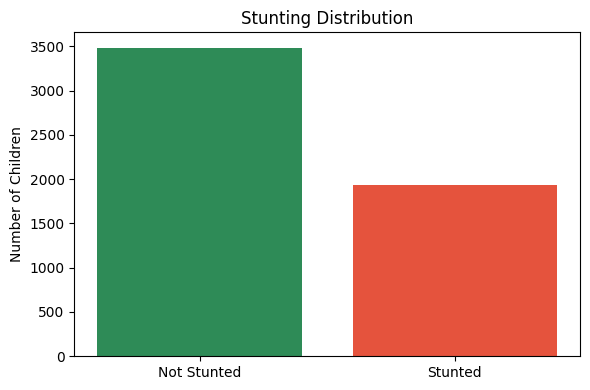

In [5]:
# Plot stunting distribution
fig, ax = plt.subplots(figsize=(6, 4))

stunting_counts = df["stunted"].value_counts().sort_index()

ax.bar(
    ["Not Stunted", "Stunted"],
    stunting_counts.values,
    color=[PRIMARY, SECONDARY]
)

ax.set_title("Stunting Distribution")
ax.set_ylabel("Number of Children")

plt.tight_layout()
plt.savefig(FIGURES / "eda_stunting_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Distribution of height for age z score

This figure shows the distribution of height for age z scores and the stunting threshold.

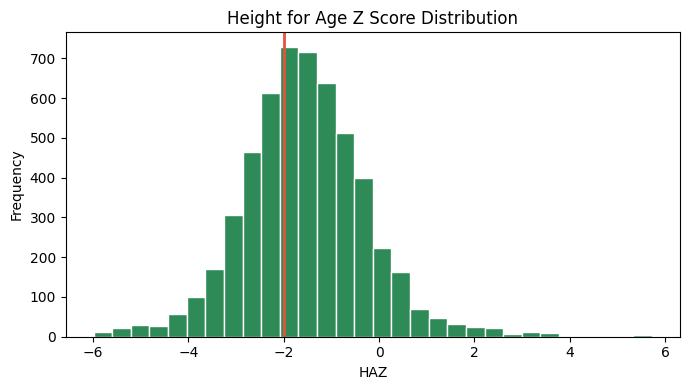

In [6]:
# Plot HAZ distribution
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["hw70"], bins=30, color=PRIMARY, edgecolor="white")

ax.axvline(-2, color=SECONDARY, linewidth=2)
ax.set_title("Height for Age Z Score Distribution")
ax.set_xlabel("HAZ")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIGURES / "eda_haz_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

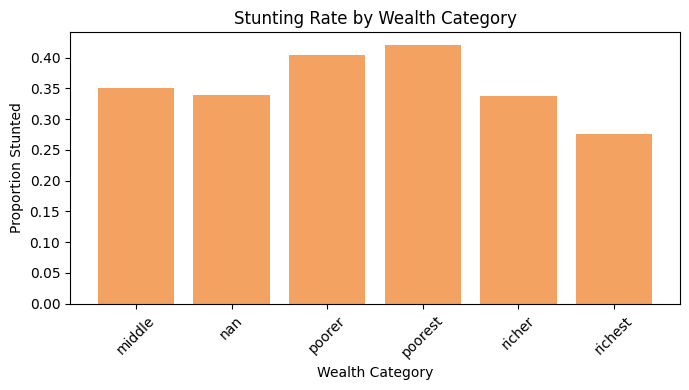

In [7]:
# Plot stunting by wealth
fig, ax = plt.subplots(figsize=(7, 4))

wealth_rates = df.groupby("v190_x")["stunted"].mean()

ax.bar(
    wealth_rates.index.astype(str),
    wealth_rates.values,
    color=ACCENT
)

ax.set_title("Stunting Rate by Wealth Category")
ax.set_ylabel("Proportion Stunted")
ax.set_xlabel("Wealth Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "eda_stunting_by_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Remove both NaN and string 'nan'
df_wealth = df[~df["v190_x"].astype(str).str.lower().eq("nan")].copy()

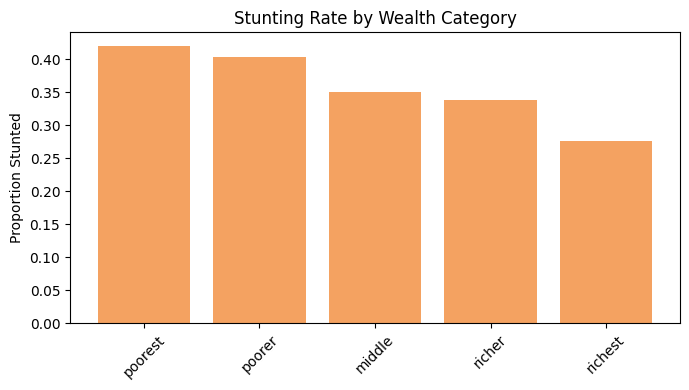

In [16]:
order = ["poorest", "poorer", "middle", "richer", "richest"]

wealth = (
    df_wealth.groupby("v190_x")["stunted"]
    .mean()
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(wealth.index, wealth.values, color=ACCENT)

ax.set_title("Stunting Rate by Wealth Category")
ax.set_ylabel("Proportion Stunted")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "eda_stunting_wealth.png", dpi=300)
plt.show()

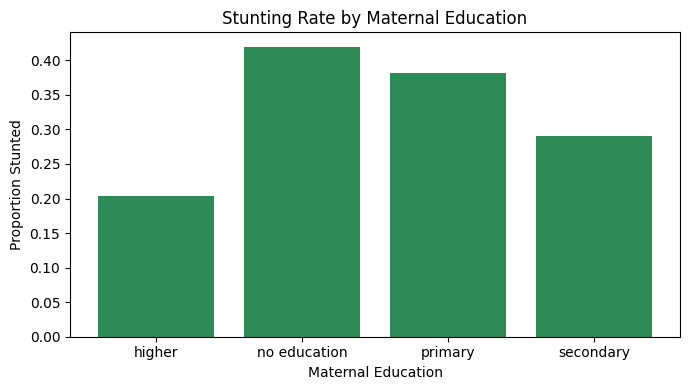

In [17]:
# Plot stunting by maternal education
fig, ax = plt.subplots(figsize=(7, 4))

education_rates = df.groupby("v106_x")["stunted"].mean()

ax.bar(
    education_rates.index.astype(str),
    education_rates.values,
    color=PRIMARY
)

ax.set_title("Stunting Rate by Maternal Education")
ax.set_ylabel("Proportion Stunted")
ax.set_xlabel("Maternal Education")

plt.tight_layout()
plt.savefig(FIGURES / "eda_stunting_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

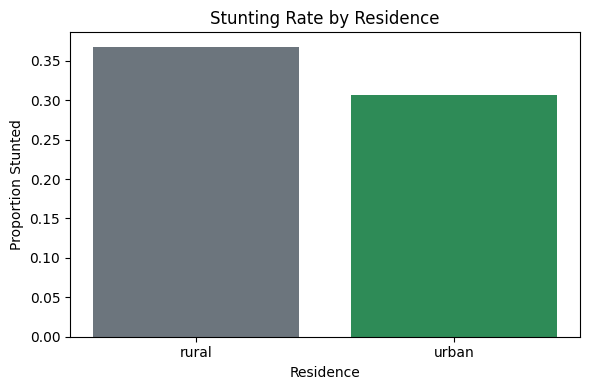

In [18]:
# Plot stunting by residence
fig, ax = plt.subplots(figsize=(6, 4))

residence_rates = df.groupby("v025_x")["stunted"].mean()

ax.bar(
    residence_rates.index.astype(str),
    residence_rates.values,
    color=[NEUTRAL, PRIMARY] if len(residence_rates) == 2 else PRIMARY
)

ax.set_title("Stunting Rate by Residence")
ax.set_ylabel("Proportion Stunted")
ax.set_xlabel("Residence")

plt.tight_layout()
plt.savefig(FIGURES / "eda_stunting_by_residence.png", dpi=300, bbox_inches="tight")
plt.show()